In [1]:
import numpy as np 

In [2]:
ddir = '/Users/ianhothi/Downloads/Fisher_Inverses_AAStar_1000h/'
TCF = np.loadtxt(ddir + 'tcf.txt',)
PdPS = np.loadtxt(ddir + 'PdPS.txt')
WST = np.loadtxt(ddir + 'wst.txt')

/Users/ianhothi/anaconda3/envs/pywst/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: covariance is not positive-semidefinite.
  if sys.path[0] == "":


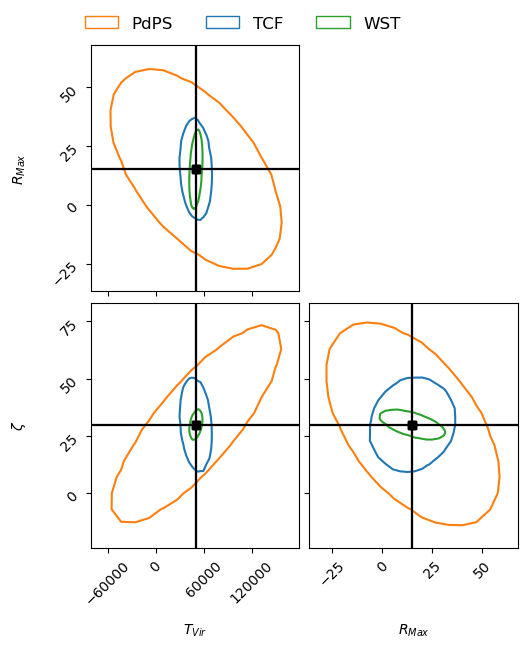

In [4]:
import corner
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Astro params
Fisher_Param = ['$T_{Vir}$', '$R_{Max}$', '$\\zeta$']
fid = [10**4.7, 15, 30]

# Posterior samples
f1 = np.random.multivariate_normal(fid, PdPS, size=100000)  # PdPS
f2 = np.random.multivariate_normal(fid, TCF, size=100000)   # TCF
f3 = np.random.multivariate_normal(fid, WST, size=100000)   # WST

# Base plot: PdPS
fig = corner.corner(
    f1,
    labels=Fisher_Param,
    truths=fid,
    truth_color='k',
    color='C1',
    show_titles=False,
    plot_datapoints=False,
    fill_contours=False,
    plot_contours=True,
    no_fill_contours=True,
    plot_density=False,
    smooth=1,
    levels=[0.95]
)

# Overlays
corner.corner(
    f2,
    fig=fig,
    color='C0',
    truths=fid,
    truth_color='k',
    plot_datapoints=False,
    fill_contours=False,
    plot_contours=True,
    no_fill_contours=True,
    plot_density=False,
    levels=[0.95]
)

corner.corner(
    f3,
    fig=fig,
    color='C2',
    truths=fid,
    truth_color='k',
    plot_datapoints=False,
    fill_contours=False,
    plot_contours=True,
    no_fill_contours=True,
    plot_density=False,
    levels=[0.95]
)
# === REMOVE UNUSED AXES ===
ndim = len(Fisher_Param)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        if i <= j:
            fig.delaxes(axes[i, j])  # remove diagonal + upper triangle

# === ZOOM INTO 2D POSTERIORS ===
samples_all = np.vstack([f1, f2, f3])  # combine all samples for consistent zoom
percentiles = [(0.05, 99.95)] * ndim  # ~covers 95% confidence for 2D projections

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        xlow, xhigh = np.percentile(f1[:, j], percentiles[j])
        ylow, yhigh = np.percentile(f1[:, i], percentiles[i])
        ax.set_xlim(xlow, xhigh)
        ax.set_ylim(ylow, yhigh)

# === LEGEND ===
legend_elements = [
    Patch(facecolor='none', edgecolor='C1', label='PdPS'),
    Patch(facecolor='none', edgecolor='C0', label='TCF'),
    Patch(facecolor='none', edgecolor='C2', label='WST')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, frameon=False, fontsize=12, bbox_to_anchor=(0.3, 1.05))

# === CLEAN LAYOUT ===
fig.subplots_adjust(top=1.33, bottom=0.33, left=0.1, right=0.95, hspace=0.05, wspace=0.05)

# === SAVE ===
plt.savefig(ddir + '/Beyond_PS_Corner.pdf',bbox_inches='tight')
